# 01. Importing Libraries

In [1]:
import os
import math
import random
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import scipy
import numpy as np
import pandas as pd
import scipy.stats as st

In [2]:
import sys
sys.path.append('..')

from src.functions import *

# 02. Importing Data

In [3]:
brazil_arrivals = pd.read_pickle('../01. Data/02. Processed Data/arrivals_10y.pkl')

In [4]:
unwto = pd.read_pickle('../01. Data/02. Processed Data/unwto_processed.pkl')

# 03. EDA

### brazil_arrivals data

In [ ]:
brazil_arrivals.info()

<class 'pandas.DataFrame'>
Index: 439438 entries, 0 to 447103
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   continent          439438 non-null  str  
 1   country_of_origin  439438 non-null  str  
 2   state              439438 non-null  str  
 3   entry_route        439438 non-null  str  
 4   year               439438 non-null  int64
 5   month              439438 non-null  str  
 6   arrivals           439438 non-null  int64
 7   covid_period       439438 non-null  str  
 8   season             439438 non-null  str  
dtypes: int64(2), str(7)
memory usage: 55.9 MB


In [ ]:
brazil_arrivals.describe()

,year,arrivals
count,439438.000000,439438.000000
mean,2019.203314,117.447770
std,2.659481,1866.321741
min,2015.000000,0.000000
25%,2017.000000,0.000000
50%,2019.000000,0.000000
75%,2021.000000,2.000000
max,2024.000000,386823.000000


In [ ]:
# checking skewness of arrivals column
brazil_arrivals['arrivals'].skew()

np.float64(91.2117014926614)

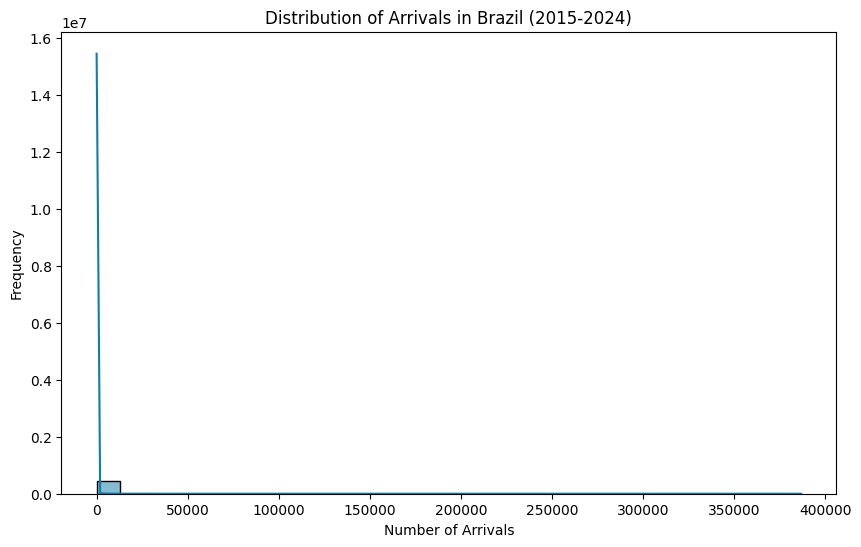

In [ ]:
# building histogram of arrivals column
arrivals_hist_br, arrivals_hist_br_ax = plt.subplots(figsize=(10,6))
sns.histplot(brazil_arrivals['arrivals'], bins=30, kde=True, ax=arrivals_hist_br_ax, color='#0D7EA8')

# adding title and labels
arrivals_hist_br_ax.set_title('Distribution of Arrivals in Brazil (2015-2024)')
arrivals_hist_br_ax.set_xlabel('Number of Arrivals')
arrivals_hist_br_ax.set_ylabel('Frequency')
plt.show()

In [ ]:
brazil_arrivals['arrivals'].kurtosis()

np.float64(14090.672205670202)

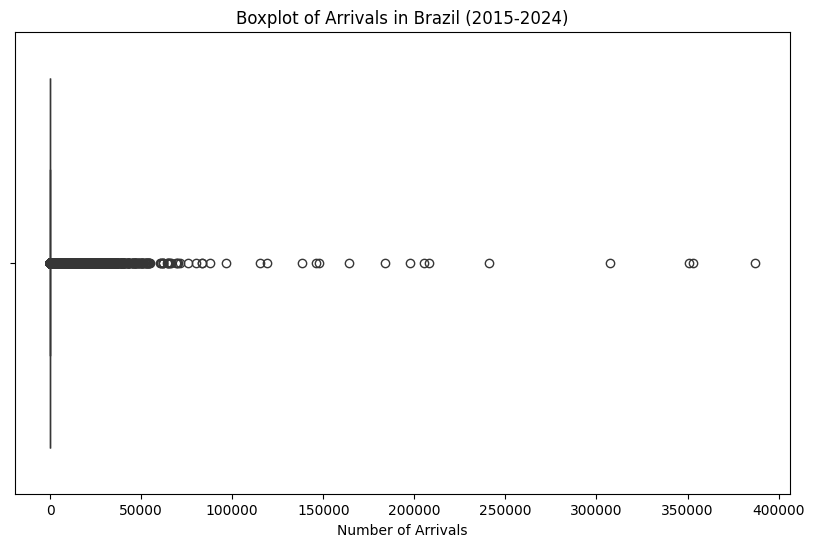

In [ ]:
# boxplot of arrivals column
arrivals_boxplot_br, arrivals_boxplot_br_ax = plt.subplots(figsize=(10,6))
sns.boxplot(x=brazil_arrivals['arrivals'], ax=arrivals_boxplot_br_ax, color='#0D7EA8')

# adding title and labels
arrivals_boxplot_br_ax.set_title('Boxplot of Arrivals in Brazil (2015-2024)')
arrivals_boxplot_br_ax.set_xlabel('Number of Arrivals')
plt.show()

In [ ]:
brazil_arrivals.sort_values('arrivals', ascending=False).head(20)

,continent,country_of_origin,state,entry_route,year,month,arrivals,covid_period,season
120553,south america,argentina,rio grande do sul,land,2017,january,386823,pre_covid,summer
31273,south america,argentina,rio grande do sul,land,2015,january,353122,pre_covid,summer
77029,south america,argentina,rio grande do sul,land,2016,january,350577,pre_covid,summer
171912,south america,argentina,rio grande do sul,land,2018,january,307324,pre_covid,summer
120646,south america,argentina,rio grande do sul,land,2017,february,241090,pre_covid,summer
171913,south america,argentina,rio grande do sul,land,2018,february,208199,pre_covid,summer
256705,south america,argentina,rio grande do sul,land,2020,january,205019,covid,summer
417148,south america,argentina,rio grande do sul,land,2023,january,197874,post_covid,summer
77122,south america,argentina,rio grande do sul,land,2016,february,183890,pre_covid,summer
31366,south america,argentina,rio grande do sul,land,2015,february,163901,pre_covid,summer


All analyses above show the same result: the distribution is heavily right-skewed, with most country/month/state combinations recording between 0–2 arrivals, but with extreme outliers reaching hundreds of thousands of arrivals per month (Argentina and Paraguay are prime examples).

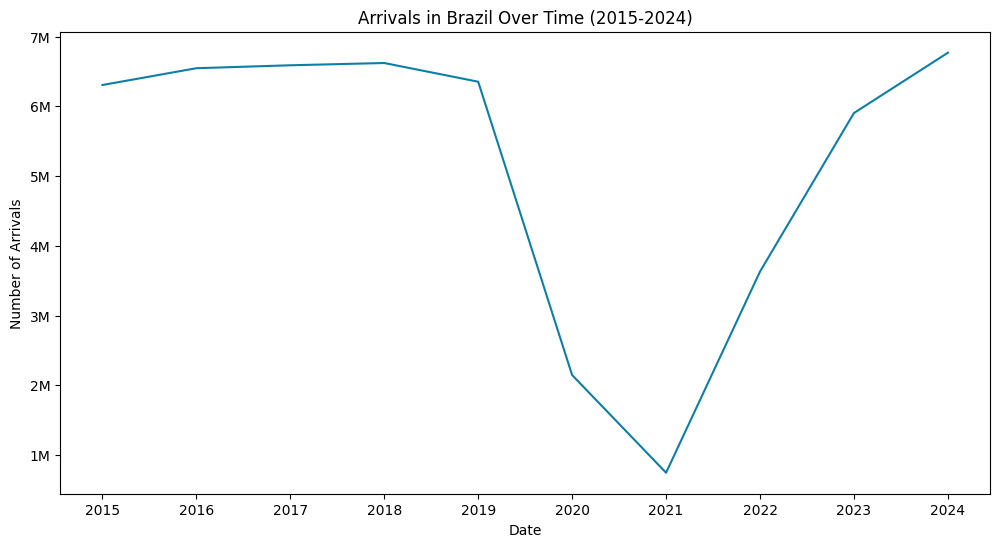

In [ ]:
# arrivals over time
arrivals_by_year = brazil_arrivals.groupby('year')['arrivals'].sum().reset_index()

arrivals_time_br, arrivals_time_br_ax = plt.subplots(figsize=(12,6))
sns.lineplot(x='year', y='arrivals', data=arrivals_by_year, ax=arrivals_time_br_ax, errorbar=None, color='#0D7EA8')

# adding title and labels
arrivals_time_br_ax.set_title('Arrivals in Brazil Over Time (2015-2024)')
arrivals_time_br_ax.set_xlabel('Date')
arrivals_time_br_ax.set_ylabel('Number of Arrivals')
arrivals_time_br_ax.set_xticks(arrivals_by_year['year'].unique())
arrivals_time_br_ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1_000_000)}M'))
plt.show()

The graph tells a clear story — 2020 and 2021 were the pandemic years and international tourism almost came to a complete halt.

Brazil's trajectory was particularly severe. The country faced significant political turbulence in its pandemic response, including the dismissal of two Health Ministers within one month, delays in vaccine procurement, and public disputes with WHO guidelines. The collapse of hospital oxygen supplies in several cities in early 2021 marked one of the lowest points of the crisis. In March 2021, international media widely criticized Brazil's pandemic management.

The deeper drop visible in 2021 (compared to 2020) reflects the delayed impact of these factors on tourism confidence and travel restrictions.

Source: https://pp.nexojornal.com.br/linha-do-tempo/2021/o-primeiro-ano-de-pandemia-no-brasil-em-43-eventos

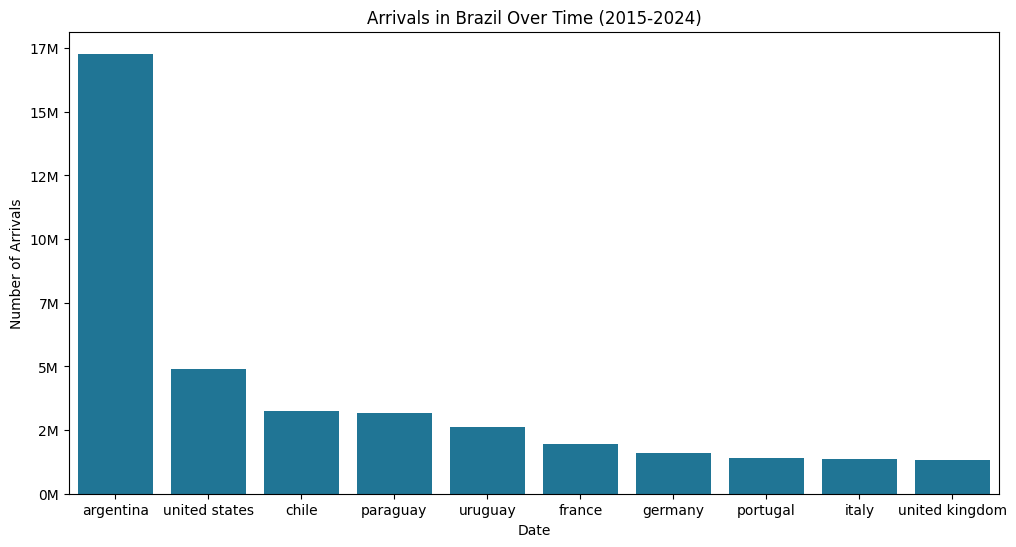

In [ ]:
# top 10 countrys of origin for arrivals in Brazil - 2015-2024
top_countries_br = brazil_arrivals.groupby('country_of_origin')['arrivals'].sum().reset_index().sort_values('arrivals', ascending=False).head(10)

top_10_br, top_10_br_ax = plt.subplots(figsize=(12,6))
sns.barplot(x='country_of_origin', y='arrivals', data=top_countries_br, ax=top_10_br_ax, errorbar=None, color='#0D7EA8')

# adding title and labels
top_10_br_ax.set_title('Arrivals in Brazil Over Time (2015-2024)')
top_10_br_ax.set_xlabel('Date')
top_10_br_ax.set_ylabel('Number of Arrivals')
top_10_br_ax.set_xticks(top_countries_br['country_of_origin'].unique())
top_10_br_ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1_000_000)}M'))
plt.show()

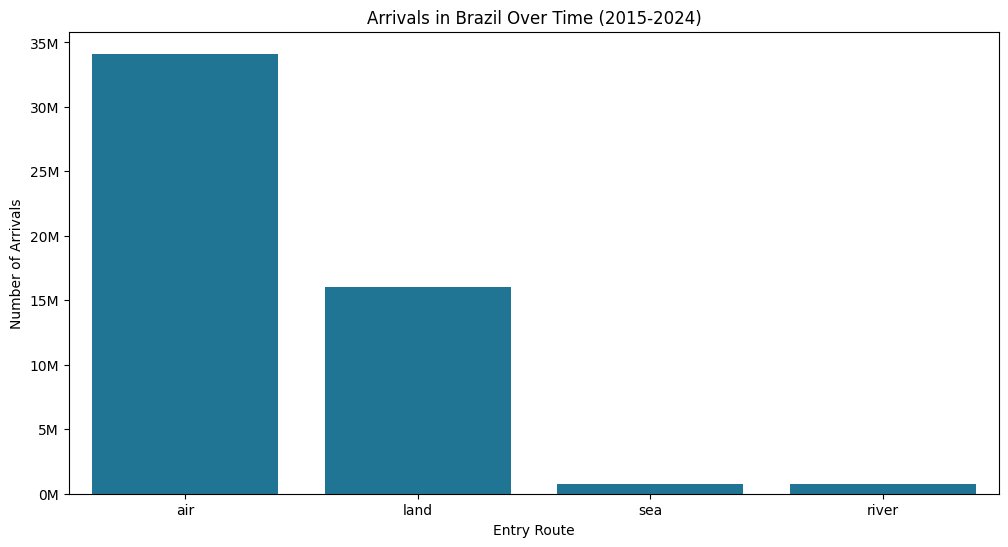

In [ ]:
# arrivals by entry_route
entry_route = brazil_arrivals.groupby('entry_route')['arrivals'].sum().reset_index().sort_values('arrivals', ascending=False).head(10)

entry_route_bar, entry_route_bar_ax = plt.subplots(figsize=(12,6))
sns.barplot(x='entry_route', y='arrivals', data=entry_route, ax=entry_route_bar_ax, errorbar=None, color='#0D7EA8')

# adding title and labels
entry_route_bar_ax.set_title('Arrivals in Brazil Over Time (2015-2024)')
entry_route_bar_ax.set_xlabel('Entry Route')
entry_route_bar_ax.set_ylabel('Number of Arrivals')
entry_route_bar_ax.set_xticks(brazil_arrivals['entry_route'].unique())
entry_route_bar_ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1_000_000)}M'))
plt.show()


In [ ]:
top_countries_br

,country_of_origin,arrivals
1,argentina,17280393
90,united states,4892642
10,chile,3232114
64,paraguay,3171061
92,uruguay,2621196
25,france,1933631
27,germany,1617011
68,portugal,1418658
40,italy,1348701
89,united kingdom,1326093


Most entries into Brazil are made by air. However, land entries are also significant, as expected given Brazil's busy land borders with several South American countries — three of which feature in the top 10 nationalities visiting Brazil. There are also some sea entries, largely driven by cruise ships (which the Turismo.gov dataset does not differentiate from overnight tourists), and a small number of river crossings, primarily at remote Amazonian border points such as the Tabatinga/Leticia tri-border area between Brazil, Colombia and Peru.

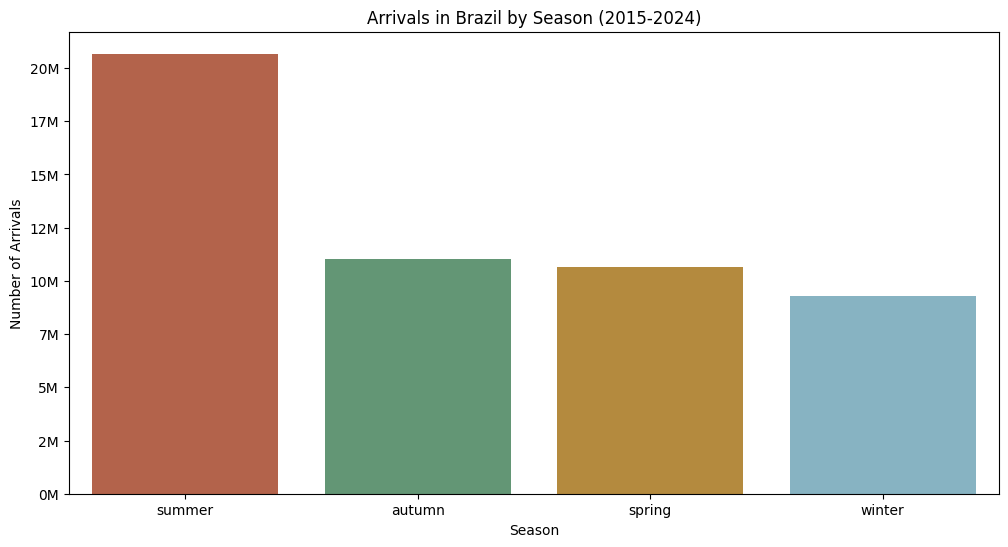

In [ ]:
# arrivals by season
arrivals_season = brazil_arrivals.groupby('season')['arrivals'].sum().reset_index().sort_values('arrivals', ascending=False)

arrivals_season_bar, arrivals_season_bar_ax = plt.subplots(figsize=(12,6))
sns.barplot(x='season', y='arrivals', hue='season',data=arrivals_season, ax=arrivals_season_bar_ax, errorbar=None,
            palette=['#5B9E72', '#C8902A', '#C45A3A', '#7DB8CC'],
            hue_order=['autumn', 'spring', 'summer', 'winter'])

# adding title and labels
arrivals_season_bar_ax.set_title('Arrivals in Brazil by Season (2015-2024)')
arrivals_season_bar_ax.set_xlabel('Season')   
arrivals_season_bar_ax.set_ylabel('Number of Arrivals')
arrivals_season_bar_ax.set_xticks(arrivals_season['season'].unique())
arrivals_season_bar_ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1_000_000)}M'))
plt.show()


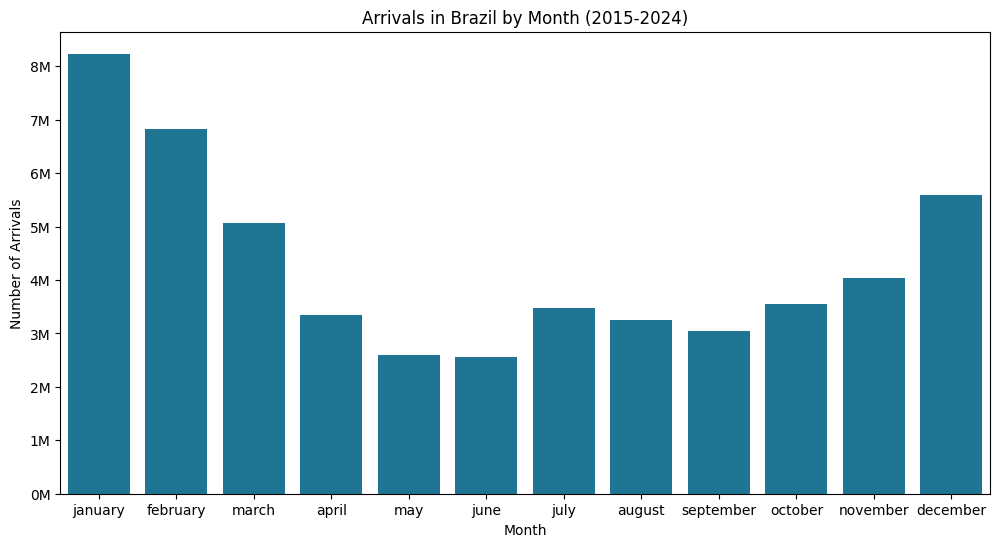

In [ ]:
# arrivals by month
month_order = ['january', 'february', 'march', 'april', 'may', 'june', 
               'july', 'august', 'september', 'october', 'november', 'december']

arrivals_month = brazil_arrivals.groupby('month')['arrivals'].sum().reset_index()
arrivals_month['month'] = pd.Categorical(arrivals_month['month'], categories=month_order, ordered=True)
arrivals_month = arrivals_month.sort_values('month')

arrivals_month_bar, arrivals_month_bar_ax = plt.subplots(figsize=(12,6))
sns.barplot(x='month', y='arrivals', data=arrivals_month, ax=arrivals_month_bar_ax, errorbar=None, color='#0D7EA8')

# adding title and labels
arrivals_month_bar_ax.set_title('Arrivals in Brazil by Month (2015-2024)')
arrivals_month_bar_ax.set_xlabel('Month')   
arrivals_month_bar_ax.set_ylabel('Number of Arrivals')
arrivals_month_bar_ax.set_xticks(arrivals_month['month'].unique())
arrivals_month_bar_ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1_000_000)}M'))
plt.show()

Both the seasonal and monthly bar charts show a clear peak in international arrivals during summer (December, January and February), which coincides with two major Brazilian events: Réveillon (New Year's) and Carnival (usually in February).

A secondary peak is visible in July and August. Despite being winter in Brazil, this likely reflects school holiday travel from the Northern Hemisphere, where July is peak summer holiday season.

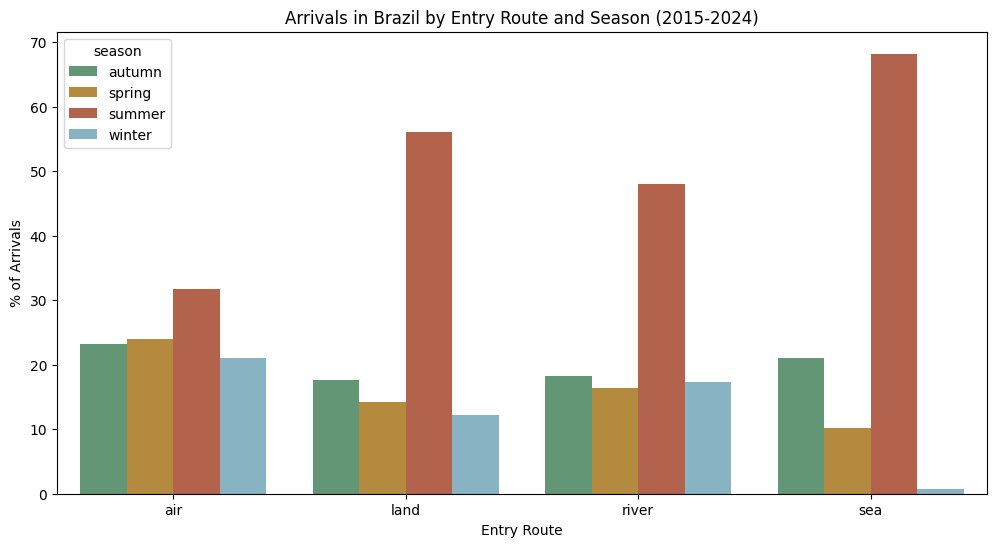

In [ ]:
# entry route by season - normalized
entry_route_season = brazil_arrivals.groupby(['entry_route', 'season'])['arrivals'].sum().reset_index()
entry_route_season['arrivals_pct'] = entry_route_season.groupby('entry_route')['arrivals'].transform(lambda x: x / x.sum() * 100)

entry_route_season_bar, entry_route_season_bar_ax = plt.subplots(figsize=(12,6))
sns.barplot(x='entry_route', y='arrivals_pct', hue='season', data=entry_route_season, ax=entry_route_season_bar_ax, errorbar=None,
            palette=['#5B9E72', '#C8902A', '#C45A3A', '#7DB8CC'])

# adding title and labels
entry_route_season_bar_ax.set_title('Arrivals in Brazil by Entry Route and Season (2015-2024)')
entry_route_season_bar_ax.set_xlabel('Entry Route')
entry_route_season_bar_ax.set_ylabel('% of Arrivals')
entry_route_season_bar_ax.set_xticks(brazil_arrivals['entry_route'].unique())   
plt.show()

Although air travel accounts for the majority of entries into Brazil, the seasonal distribution is relatively balanced across all seasons for this route. 

Sea and river entries, however, show a strong summer peak. These modes of transport are more weather-dependent — whether due to open river crossings or cruise ship seasonality. The near-zero sea entries in winter suggest that the vast majority of sea arrivals are cruise ship passengers, as cruise season aligns with the Southern Hemisphere summer.

Land entries also show a notable summer peak, which at first glance is surprising given that land borders are not affected by weather. However, this makes perfect sense when considering that southern Brazilian beach destinations are heavily visited by Argentine and Paraguayan tourists during the summer months — two of the top origin countries in the dataset.

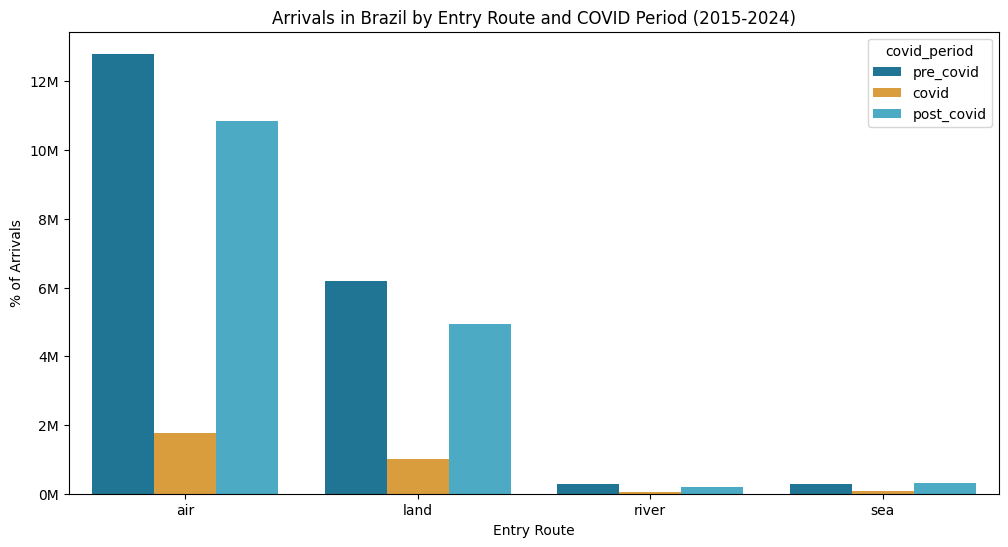

In [ ]:
# entry route by covid period
entry_route_covid = brazil_arrivals[brazil_arrivals['year'].isin([2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])].groupby(['entry_route', 'covid_period'])['arrivals'].sum().reset_index()

entry_route_covid_bar, entry_route_covid_bar_ax = plt.subplots(figsize=(12,6))
sns.barplot(x='entry_route', y='arrivals', hue='covid_period', data=entry_route_covid, ax=entry_route_covid_bar_ax, errorbar=None,
            palette=['#0D7EA8', '#F4A324', '#38B6D8'],
            hue_order=['pre_covid', 'covid', 'post_covid'])

# adding title and labels
entry_route_covid_bar_ax.set_title('Arrivals in Brazil by Entry Route and COVID Period (2015-2024)')
entry_route_covid_bar_ax.set_xlabel('Entry Route')  
entry_route_covid_bar_ax.set_ylabel('% of Arrivals')
entry_route_covid_bar_ax.set_xticks(brazil_arrivals['entry_route'].unique())
entry_route_covid_bar_ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1_000_000)}M'))
plt.show()

Comparing the same number of years before and after COVID (2017–2019 vs 2022–2024), air and land entries are still recovering and have not yet reached pre-pandemic levels. River and sea entries, however, have already fully recovered in absolute numbers — an interesting finding given that sea tourism (cruise ships) was expected to be one of the slowest to bounce back.

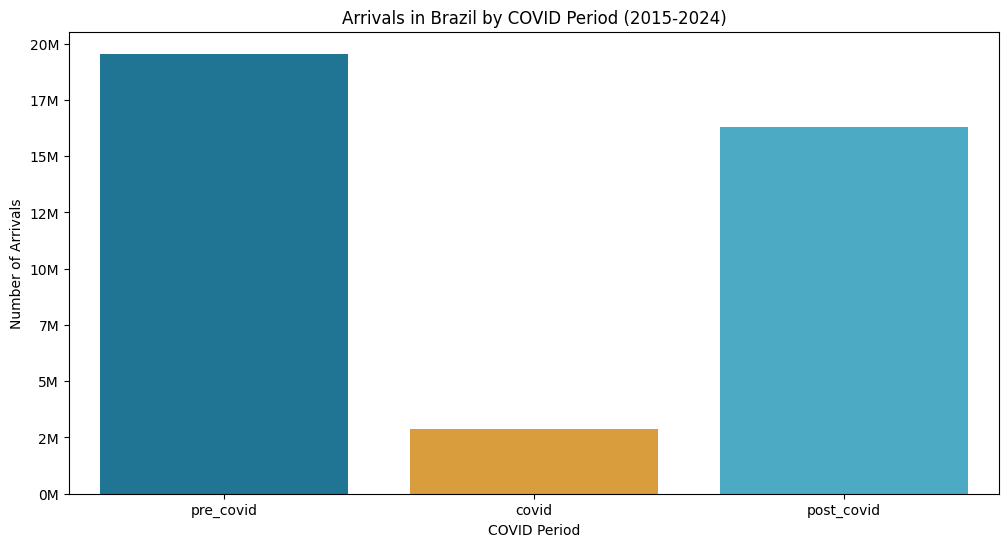

In [ ]:
# arrivals by covid label
arrivals_covid = brazil_arrivals[brazil_arrivals['year'].isin([2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])].groupby('covid_period')['arrivals'].sum().reset_index()

arrivals_covid_bar, arrivals_covid_bar_ax = plt.subplots(figsize=(12,6))

sns.barplot(x='covid_period', y='arrivals', data=arrivals_covid, ax=arrivals_covid_bar_ax, errorbar=None,
            hue='covid_period', legend=False,
            palette=['#0D7EA8', '#F4A324', '#38B6D8'], 
            order=['pre_covid', 'covid', 'post_covid'],
            hue_order=['pre_covid', 'covid', 'post_covid'])

# adding title and labels
arrivals_covid_bar_ax.set_title('Arrivals in Brazil by COVID Period (2015-2024)')
arrivals_covid_bar_ax.set_xlabel('COVID Period')        
arrivals_covid_bar_ax.set_ylabel('Number of Arrivals')
arrivals_covid_bar_ax.set_xticks(arrivals_covid['covid_period'].unique())
arrivals_covid_bar_ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1_000_000)}M'))
plt.show()

Comparing the same number of years before and after COVID (2017–2019 vs 2022–2024), Brazil has not yet reached the same total number of international arrivals as in the pre-pandemic period. Recovery is underway but the gap remains significant.

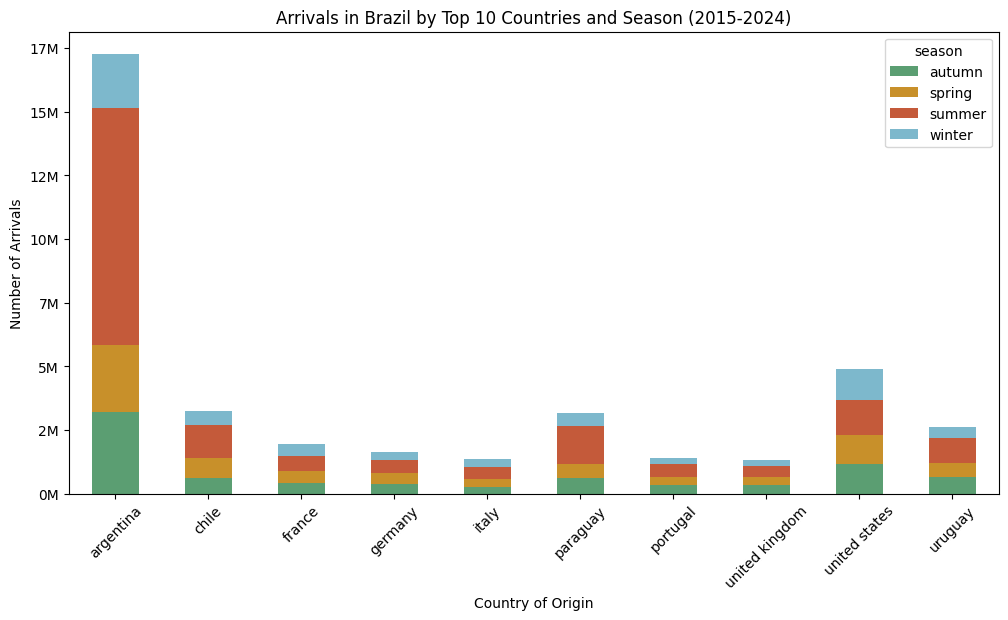

In [ ]:
# arrivals per country of origin per month/season
top10_countries = brazil_arrivals.groupby('country_of_origin')['arrivals'].sum().nlargest(10).index

arrivals_country_season = brazil_arrivals[brazil_arrivals['country_of_origin'].isin(top10_countries)].groupby(['country_of_origin', 'season'])['arrivals'].sum().reset_index()

arrivals_country_season_pivot = arrivals_country_season.pivot(index='country_of_origin', columns='season', values='arrivals')

arrivals_country_season_bar, arrivals_country_season_bar_ax = plt.subplots(figsize=(12,6))
arrivals_country_season_pivot.plot(kind='bar', stacked=True, ax=arrivals_country_season_bar_ax,
                                    color=['#5B9E72', '#C8902A', '#C45A3A', '#7DB8CC'])

# adding title and labels
arrivals_country_season_bar_ax.set_title('Arrivals in Brazil by Top 10 Countries and Season (2015-2024)')
arrivals_country_season_bar_ax.set_xlabel('Country of Origin')
arrivals_country_season_bar_ax.set_ylabel('Number of Arrivals')
arrivals_country_season_bar_ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1_000_000)}M'))
plt.xticks(rotation=45)
plt.show()

This chart supports the earlier finding that the summer peak in land entries is driven by Argentine and Paraguayan tourists visiting southern Brazilian beaches — both countries show a significantly higher proportion of arrivals in summer compared to other seasons. 

North Hemisphere countries (France, Germany, Italy, United Kingdom, United States) show a much more balanced seasonal distribution, suggesting that their travel to Brazil is not strongly tied to any particular season — likely driven by business travel, city tourism and cultural interest rather than beach holidays.

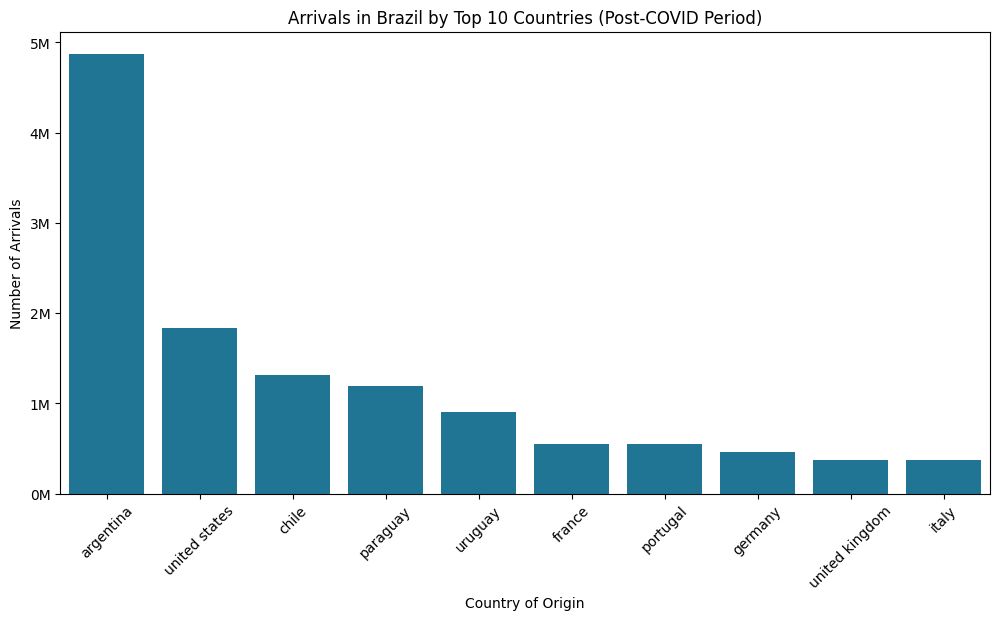

In [ ]:
# top 10 countries after covid
top_countries_postcovid = brazil_arrivals[brazil_arrivals['covid_period'].isin(['post_covid'])].groupby('country_of_origin')['arrivals'].sum().reset_index().sort_values('arrivals', ascending=False).head(10)
top_countries_postcovid_bar, top_countries_postcovid_bar_ax = plt.subplots(figsize=(12,6))
sns.barplot(x='country_of_origin', y='arrivals', data=top_countries_postcovid, ax=top_countries_postcovid_bar_ax, errorbar=None, color='#0D7EA8')

# adding title and labels
top_countries_postcovid_bar_ax.set_title('Arrivals in Brazil by Top 10 Countries (Post-COVID Period)')
top_countries_postcovid_bar_ax.set_xlabel('Country of Origin')
top_countries_postcovid_bar_ax.set_ylabel('Number of Arrivals')
top_countries_postcovid_bar_ax.set_xticks(top_countries_postcovid['country_of_origin'].unique())
top_countries_postcovid_bar_ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1_000_000)}M'))
plt.xticks(rotation=45)
plt.show()

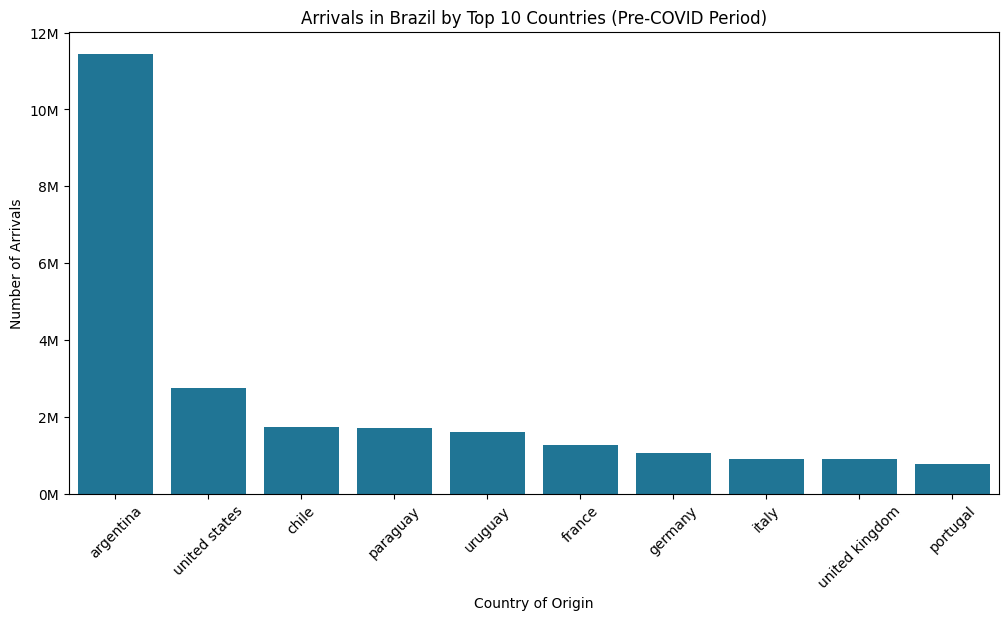

In [ ]:
# top 10 countries before covid
top_countries_precovid = brazil_arrivals[brazil_arrivals['covid_period'].isin(['pre_covid'])].groupby('country_of_origin')['arrivals'].sum().reset_index().sort_values('arrivals', ascending=False).head(10)
top_countries_precovid_bar, top_countries_precovid_bar_ax = plt.subplots(figsize=(12,6))
sns.barplot(x='country_of_origin', y='arrivals', data=top_countries_precovid, ax=top_countries_precovid_bar_ax, errorbar=None, color='#0D7EA8')

# adding title and labels
top_countries_precovid_bar_ax.set_title('Arrivals in Brazil by Top 10 Countries (Pre-COVID Period)')
top_countries_precovid_bar_ax.set_xlabel('Country of Origin')
top_countries_precovid_bar_ax.set_ylabel('Number of Arrivals')
top_countries_precovid_bar_ax.set_xticks(top_countries_precovid['country_of_origin'].unique())
top_countries_precovid_bar_ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1_000_000)}M'))
plt.xticks(rotation=45)
plt.show()

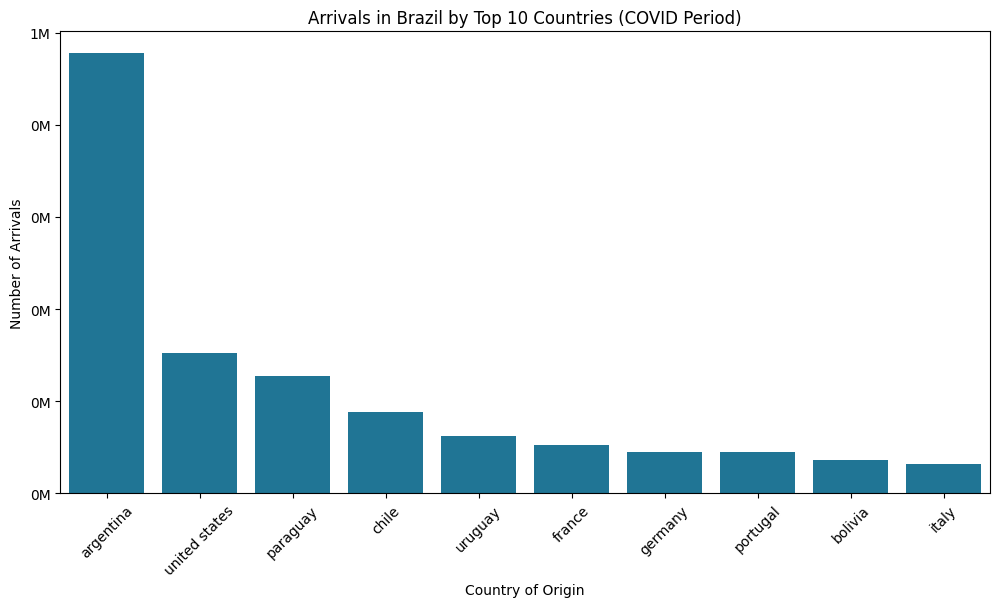

In [ ]:
# top 10 countries during covid
top_countries_covid = brazil_arrivals[brazil_arrivals['covid_period'].isin(['covid'])].groupby('country_of_origin')['arrivals'].sum().reset_index().sort_values('arrivals', ascending=False).head(10)
top_countries_covid_bar, top_countries_covid_bar_ax = plt.subplots(figsize=(12,6))
sns.barplot(x='country_of_origin', y='arrivals', data=top_countries_covid, ax=top_countries_covid_bar_ax, errorbar=None, color='#0D7EA8')

# adding title and labels
top_countries_covid_bar_ax.set_title('Arrivals in Brazil by Top 10 Countries (COVID Period)')
top_countries_covid_bar_ax.set_xlabel('Country of Origin')
top_countries_covid_bar_ax.set_ylabel('Number of Arrivals')
top_countries_covid_bar_ax.set_xticks(top_countries_covid['country_of_origin'].unique())
top_countries_covid_bar_ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1_000_000)}M'))
plt.xticks(rotation=45)
plt.show()

The top 10 origin countries remain largely consistent across all three periods, with only minor position changes towards the bottom of the ranking. One interesting finding during the COVID period is the appearance of Bolivia in the top 10 — as international long-haul tourism came to a near halt, neighbouring countries that share land borders with Brazil continued crossing, making Bolivia's relative share more visible in the ranking.

#### UNWTO data

In [ ]:
unwto.info()

<class 'pandas.DataFrame'>
Index: 2415 entries, 1888 to 10073
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   type_of_arrival  2415 non-null   str  
 1   country_name     2415 non-null   str  
 2   year             2415 non-null   int64
 3   arrivals         2415 non-null   int64
 4   covid_period     2415 non-null   str  
 5   continent        2415 non-null   str  
dtypes: int64(2), str(4)
memory usage: 240.7 KB


In [ ]:
unwto.describe()

,year,arrivals
count,2415.000000,2.415000e+03
mean,2018.749896,5.641825e+06
std,2.600183,1.386572e+07
min,2015.000000,0.000000e+00
25%,2017.000000,1.640000e+05
50%,2019.000000,8.070000e+05
75%,2021.000000,3.517000e+06
max,2024.000000,1.269630e+08


In [ ]:
# checking skewness of arrivals column
unwto['arrivals'].skew()

np.float64(4.345373432477026)

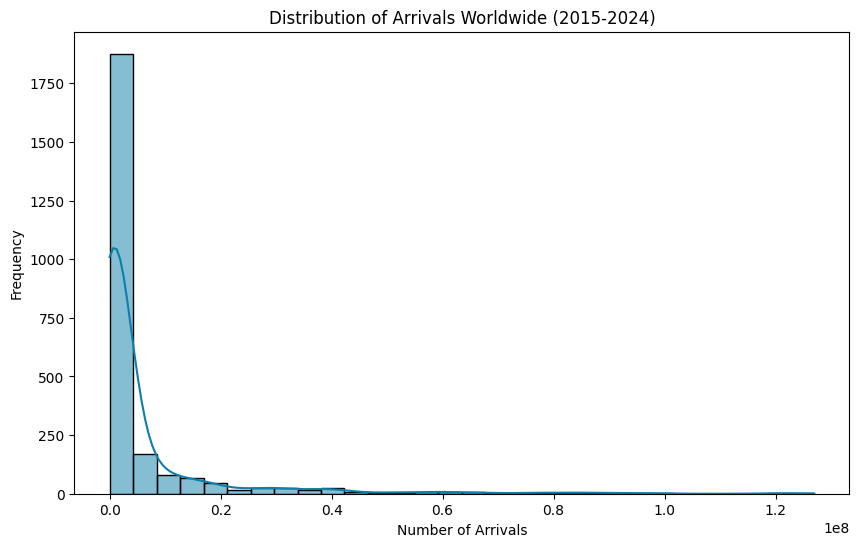

In [ ]:
# building histogram of arrivals column
arrivals_hist_unwto, arrivals_hist_unwto_ax = plt.subplots(figsize=(10,6))
sns.histplot(unwto['arrivals'], bins=30, kde=True, ax=arrivals_hist_unwto_ax, color='#0D7EA8')

# adding title and labels
arrivals_hist_unwto_ax.set_title('Distribution of Arrivals Worldwide (2015-2024)')
arrivals_hist_unwto_ax.set_xlabel('Number of Arrivals')
arrivals_hist_unwto_ax.set_ylabel('Frequency')
plt.show()

In [ ]:
unwto['arrivals'].kurtosis()

np.float64(22.722424246557054)

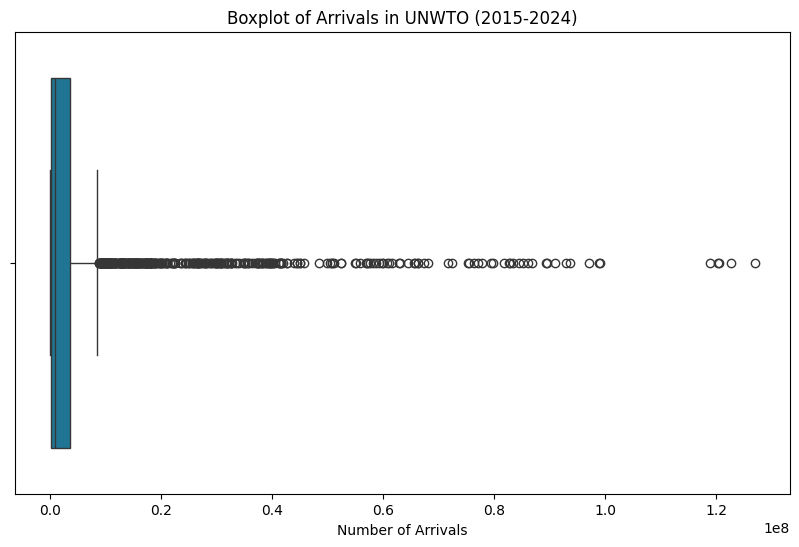

In [ ]:
# boxplot of arrivals column
arrivals_boxplot_unwto, arrivals_boxplot_unwto_ax = plt.subplots(figsize=(10,6), )
sns.boxplot(x=unwto['arrivals'], ax=arrivals_boxplot_unwto_ax, color='#0D7EA8')

# adding title and labels
arrivals_boxplot_unwto_ax.set_title('Boxplot of Arrivals in UNWTO (2015-2024)')
arrivals_boxplot_unwto_ax.set_xlabel('Number of Arrivals')
plt.show()

In [ ]:
unwto.sort_values('arrivals', ascending=False).head(20)

,type_of_arrival,country_name,year,arrivals,covid_period,continent
7896,same-day visitor,france,2019,126963000,pre_covid,europe
7895,same-day visitor,france,2018,122676000,pre_covid,europe
7894,same-day visitor,france,2017,120516000,pre_covid,europe
7893,same-day visitor,france,2016,120360000,pre_covid,europe
7892,same-day visitor,france,2015,118851000,pre_covid,europe
9970,same-day visitor,united states,2015,99091000,pre_covid,north america
9971,same-day visitor,united states,2016,98854000,pre_covid,north america
9972,same-day visitor,united states,2017,97105000,pre_covid,north america
6280,overnight tourist,spain,2024,93759297,post_covid,europe
7898,same-day visitor,france,2021,92902000,covid,europe


This dataset also shows right skewness, though less extreme than the Brazilian one. It is aggregated at country/year level, with no monthly breakdown. 75% of country/year combinations record fewer than 3,517,000 arrivals per year. Outliers include France, the USA and Spain — countries globally renowned for their tourism volume.

Unlike the Brazilian dataset which records overall arrivals without distinguishing visitor type, the UNWTO dataset separates overnight tourists from same-day visitors, providing greater granularity on the nature of each trip.

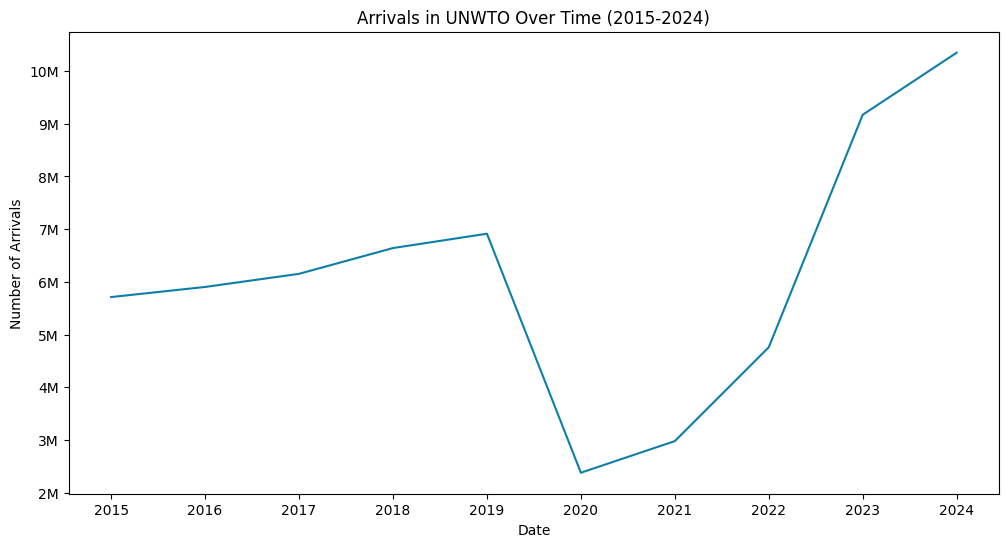

In [ ]:
# arrivals over time
arrivals_time_unwto, arrivals_time_unwto_ax = plt.subplots(figsize=(12,6))
sns.lineplot(x='year', y='arrivals', data=unwto, ax=arrivals_time_unwto_ax, errorbar=None, color='#0D7EA8')

# adding title and labels
arrivals_time_unwto_ax.set_title('Arrivals in UNWTO Over Time (2015-2024)')
arrivals_time_unwto_ax.set_xlabel('Date')
arrivals_time_unwto_ax.set_ylabel('Number of Arrivals')
arrivals_time_unwto_ax.set_xticks(unwto['year'].unique())
arrivals_time_unwto_ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1_000_000)}M'))
plt.show()

The graph tells a clear story (just as the Brazil one). The COVID-19 pandemic brought international tourism to an almost complete halt in 2020. As vaccination campaigns began in late 2020, some travel resumed, but the Omicron variant in early 2021 continued to suppress movement. Only from 2022 onwards did the world fully reopen to tourism. Since then, arrivals have been rising steadily and, by 2023, numbers have surpassed pre-pandemic levels.

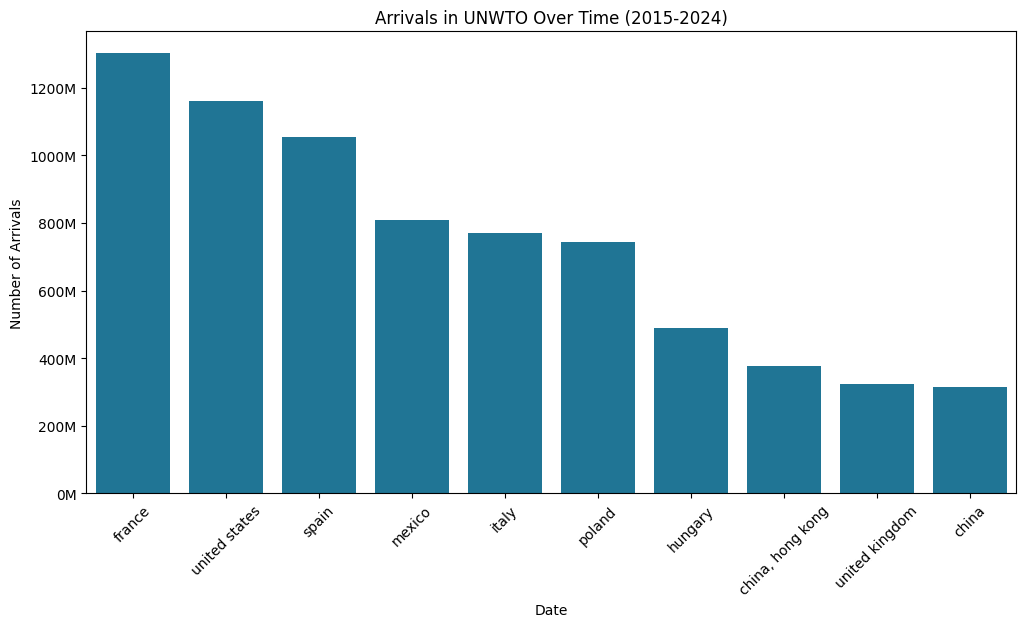

In [ ]:
# top 10 countrys receiving visitors - 2015-2024
top_countries_unwto = unwto.groupby('country_name')['arrivals'].sum().reset_index().sort_values('arrivals', ascending=False).head(10)

top_10_unwto, top_10_unwto_ax = plt.subplots(figsize=(12,6))
sns.barplot(x='country_name', y='arrivals', data=top_countries_unwto, ax=top_10_unwto_ax, errorbar=None, color='#0D7EA8')

# adding title and labels
top_10_unwto_ax.set_title('Arrivals in UNWTO Over Time (2015-2024)')
top_10_unwto_ax.set_xlabel('Date')
top_10_unwto_ax.set_ylabel('Number of Arrivals')
top_10_unwto_ax.set_xticks(top_countries_unwto['country_name'].unique())
top_10_unwto_ax.tick_params(axis='x', rotation=45)
top_10_unwto_ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1_000_000)}M'))
plt.show()

In [ ]:
# sum of all arivals in Brasil 2015-2024, according to turismo.gov data
brazil_arrivals['arrivals'].sum()

np.int64(51611013)

In [ ]:
# sum of all arivals in Brasil 2015-2024, according to unwto data
unwto.groupby('country_name')['arrivals'].sum().loc['brazil']

np.int64(51620297)

Despite its size and global recognition, Brazil does not feature in the top 20 most visited destinations worldwide. Even China, historically a more restrictive country in terms of tourism, received significantly more international visitors than Brazil in the same period (approximately 200M vs 51.6M). This highlights a significant untapped potential in Brazil's international tourism market.

# 04. Visualizations Export

In [ ]:
# turismot.gov ones
arrivals_hist_br.savefig('../03. Visualizations/Python/arrivals_distribution.png', dpi=300, bbox_inches='tight')
arrivals_boxplot_br.savefig('../03. Visualizations/Python/arrivals_boxplot.png', dpi=300, bbox_inches='tight')
arrivals_time_br.savefig('../03. Visualizations/Python/arrivals_over_time_brazil.png', dpi=300, bbox_inches='tight')
top_10_br.savefig('../03. Visualizations/Python/top10_countries_brazil.png', dpi=300, bbox_inches='tight')
entry_route_bar.savefig('../03. Visualizations/Python/arrivals_by_entry_route.png', dpi=300, bbox_inches='tight')
arrivals_season_bar.savefig('../03. Visualizations/Python/arrivals_by_season.png', dpi=300, bbox_inches='tight')
arrivals_month_bar.savefig('../03. Visualizations/Python/arrivals_by_month.png', dpi=300, bbox_inches='tight')
entry_route_season_bar.savefig('../03. Visualizations/Python/entry_route_by_season.png', dpi=300, bbox_inches='tight')
entry_route_covid_bar.savefig('../03. Visualizations/Python/entry_route_by_covid.png', dpi=300, bbox_inches='tight')
arrivals_covid_bar.savefig('../03. Visualizations/Python/arrivals_by_covid_period.png', dpi=300, bbox_inches='tight')
arrivals_country_season_bar.savefig('../03. Visualizations/Python/top10_countries_by_season.png', dpi=300, bbox_inches='tight')
top_countries_postcovid_bar.savefig('../03. Visualizations/Python/top10_countries_post_covid.png', dpi=300, bbox_inches='tight')
top_countries_precovid_bar.savefig('../03. Visualizations/Python/top10_countries_pre_covid.png', dpi=300, bbox_inches='tight')
top_countries_covid_bar.savefig('../03. Visualizations/Python/top10_countries_covid.png', dpi=300, bbox_inches='tight')

In [ ]:
# unwto ones
arrivals_hist_unwto.savefig('../03. Visualizations/Python/arrivals_distribution_unwto.png', dpi=300, bbox_inches='tight')
arrivals_boxplot_unwto.savefig('../03. Visualizations/Python/arrivals_boxplot_unwto.png', dpi=300, bbox_inches='tight')
arrivals_time_unwto.savefig('../03. Visualizations/Python/arrivals_over_time_unwto.png', dpi=300, bbox_inches='tight')
top_10_unwto.savefig('../03. Visualizations/Python/top10_countries_unwto.png', dpi=300, bbox_inches='tight')  


# 05. Extra information for Tableau Dashboard

In [12]:
# World total arrivals 2015-2024
total_10y = unwto[unwto['year'].between(2015, 2024)]['arrivals'].sum()
print(f'Total world arrivals 2015-2024: {total_10y:,.0f}')

# World total arrivals 2024
total_2024 = unwto[unwto['year'] == 2024]['arrivals'].sum()
print(f'Total world arrivals 2024: {total_2024:,.0f}')

# Brazil ranking 2024
ranking_2024 = unwto[unwto['year'] == 2024].groupby('country_name')['arrivals'].sum().sort_values(ascending=False).reset_index()
ranking_2024['rank'] = ranking_2024['arrivals'].rank(ascending=False).astype(int)
brazil_rank_2024 = ranking_2024[ranking_2024['country_name'] == 'brazil']['rank'].values[0]
brazil_arrivals_2024 = ranking_2024[ranking_2024['country_name'] == 'brazil']['arrivals'].values[0]
print(f'Brazil arrivals 2024: {brazil_arrivals_2024:,.0f}')
print(f'Brazil world ranking 2024: #{brazil_rank_2024}')

# Brazil ranking 2015-2024
ranking_10y = unwto[unwto['year'].between(2015, 2024)].groupby('country_name')['arrivals'].sum().sort_values(ascending=False).reset_index()
ranking_10y['rank'] = ranking_10y['arrivals'].rank(ascending=False).astype(int)
brazil_rank_10y = ranking_10y[ranking_10y['country_name'] == 'brazil']['rank'].values[0]
print(f'Brazil world ranking 2015-2024: #{brazil_rank_10y}')

Total world arrivals 2015-2024: 13,625,008,450
Total world arrivals 2024: 1,076,038,014
Brazil arrivals 2024: 6,773,619
Brazil world ranking 2024: #32
Brazil world ranking 2015-2024: #47


In [14]:
# Brazil ranking 2015-2023
ranking_10y = unwto[unwto['year'].between(2015, 2023)].groupby('country_name')['arrivals'].sum().sort_values(ascending=False).reset_index()
ranking_10y['rank'] = ranking_10y['arrivals'].rank(ascending=False).astype(int)
brazil_rank_10y = ranking_10y[ranking_10y['country_name'] == 'brazil']['rank'].values[0]
print(f'Brazil world ranking 2015-2023: #{brazil_rank_10y}')

Brazil world ranking 2015-2023: #47


In [ ]:
# checking number for KPI cards
brazil_arrivals['arrivals'].sum()

np.int64(51611013)